c:\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


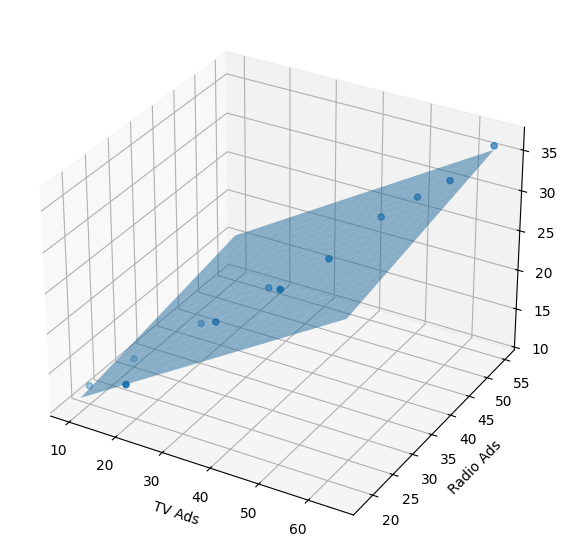

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ---------------------------
# 1. Load the Dataset
# ---------------------------
data = {
    'TV_Ads': [10,15,20,25,30,35,40,45,50,55,60,65],
    'Radio_Ads': [20,25,18,30,28,35,32,38,45,48,50,55],
    'Sales': [12,14,15,18,20,22,24,26,29,31,33,36]
}

df = pd.DataFrame(data)

X = df[['TV_Ads', 'Radio_Ads']]
y = df['Sales']

# ---------------------------
# 2. Train the Model
# ---------------------------
model = LinearRegression()
model.fit(X, y)

# ---------------------------
# 3. 3D Plot
# ---------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Actual points
ax.scatter(df['TV_Ads'], df['Radio_Ads'], df['Sales'])

# Create meshgrid for plane
x_surf, y_surf = np.meshgrid(
    np.linspace(df.TV_Ads.min(), df.TV_Ads.max(), 20),
    np.linspace(df.Radio_Ads.min(), df.Radio_Ads.max(), 20)
)

# Predict over the grid
z_surf = model.predict(np.array([x_surf.ravel(), y_surf.ravel()]).T)
z_surf = z_surf.reshape(x_surf.shape)

# Surface plot
ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.5)

ax.set_xlabel('TV Ads')
ax.set_ylabel('Radio Ads')
ax.set_zlabel('Sales')
plt.show()
